In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from config import DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, FEATURE_NAMES_PATH


In [2]:
df = pd.read_csv(DATA_PROCESSED / "diabetic_cohort_preprocessed.csv")
y = df["readmission_30"]
groups = df["patient_id"]
X = df.drop(columns=["readmission_30", "patient_id"])
feature_names = list(X.columns)

print(f"Cohort: {X.shape[0]} patients, {X.shape[1]} features")


Cohort: 62232 patients, 18 features


In [3]:
SEARCH_SPACES = {
    "LogisticRegression": {
        "clf__C": [0.001, 0.01, 0.1, 0.3, 1, 3, 10, 30],
        "clf__solver": ["lbfgs", "liblinear"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 300, 400, 600, 800, 1000],
        "clf__max_depth": [None, 3, 5, 8, 10, 15, 20],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2", None],
    },
    "XGBoost": {
        "clf__max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
        "clf__learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2],
        "clf__n_estimators": [100, 200, 300, 400, 600, 800, 1000],
        "clf__subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        "clf__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        "clf__min_child_weight": [1, 2, 3, 5, 7, 10],
        "clf__gamma": [0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0],
        "clf__reg_alpha": [0, 0.001, 0.01, 0.1, 0.5, 1, 2],
        "clf__reg_lambda": [0.1, 0.5, 1, 1.5, 2, 3, 5],
    },
    "LightGBM": {
        "clf__num_leaves": [15, 31, 63, 127, 255],
        "clf__learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2],
        "clf__n_estimators": [100, 200, 300, 400, 600, 800, 1000],
        "clf__subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        "clf__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        "clf__min_child_samples": [5, 10, 20, 30, 50],
        "clf__reg_alpha": [0, 0.001, 0.01, 0.1, 0.5, 1, 2],
        "clf__reg_lambda": [0.1, 0.5, 1, 1.5, 2, 3, 5],
    },
    "CatBoost": {
       "clf__depth": [4, 6, 8],
        "clf__learning_rate": [0.05,0.1],
        "clf__iterations": [100, 200],
        "clf__l2_leaf_reg": [1, 3, 5, 7, 9, 12],
        "clf__bagging_temperature": [1, 2],
    },
    "MLP": {
        "clf__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
        "clf__alpha": [0.0001, 0.001, 0.01, 0.1],
        "clf__learning_rate_init": [0.0005, 0.001, 0.005, 0.01],
    },
}

N_ITER_PER_MODEL = {
    "LogisticRegression": 8,
    "RandomForest": 20,
    "XGBoost": 40,
    "LightGBM": 40,
    "CatBoost": 20,
    "MLP": 20,
}

BASE_ESTIMATORS = {
    "LogisticRegression": lambda: LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": lambda: RandomForestClassifier(random_state=42, n_jobs=1),
    "XGBoost": lambda: XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=1),
    "LightGBM": lambda: LGBMClassifier(random_state=42, verbose=-1, n_jobs=1),
    "CatBoost": lambda: CatBoostClassifier(verbose=0, random_state=42, thread_count=1),
    "MLP": lambda: MLPClassifier(max_iter=300, early_stopping=True, random_state=42),
}


In [ ]:
cv_splits = list(GroupKFold(n_splits=5).split(X, y, groups))

tuned_params = {}
tuning_summary = []

for model_name, n_iter in N_ITER_PER_MODEL.items():
    print(f"Tuning {model_name} (n_iter={n_iter})...")

    pipeline = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("clf", BASE_ESTIMATORS[model_name]()),
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=SEARCH_SPACES[model_name],
        n_iter=n_iter,
        scoring="f1",
        cv=cv_splits,
        random_state=42,
        n_jobs=-1,
        error_score="raise",
    )
    search.fit(X, y)

    best_params = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    tuned_params[model_name] = best_params
    tuning_summary.append({"model": model_name, "tuned_cv_f1": search.best_score_})
    print(f"  {model_name}: tuned CV F1 = {search.best_score_:.4f}")

print("\nTuning summary (search-phase estimate, not the held-out benchmark below):")
print(pd.DataFrame(tuning_summary).sort_values("tuned_cv_f1", ascending=False).to_string(index=False))

MODELS = {
    "LogisticRegression": lambda p=tuned_params["LogisticRegression"]: LogisticRegression(max_iter=1000, random_state=42, **p),
    "RandomForest": lambda p=tuned_params["RandomForest"]: RandomForestClassifier(random_state=42, **p),
    "XGBoost": lambda p=tuned_params["XGBoost"]: XGBClassifier(eval_metric="logloss", random_state=42, **p),
    "LightGBM": lambda p=tuned_params["LightGBM"]: LGBMClassifier(random_state=42, verbose=-1, **p),
    "CatBoost": lambda p=tuned_params["CatBoost"]: CatBoostClassifier(verbose=0, random_state=42, **p),
    "MLP": lambda p=tuned_params["MLP"]: MLPClassifier(max_iter=300, early_stopping=True, random_state=42, **p),
}


Tuning LogisticRegression (n_iter=8)...
  LogisticRegression: tuned CV F1 = 0.6391
Tuning RandomForest (n_iter=20)...
  RandomForest: tuned CV F1 = 0.6396
Tuning XGBoost (n_iter=40)...
  XGBoost: tuned CV F1 = 0.6477
Tuning LightGBM (n_iter=40)...
  LightGBM: tuned CV F1 = 0.6449
Tuning CatBoost (n_iter=20)...
  CatBoost: tuned CV F1 = 0.6459
Tuning MLP (n_iter=20)...
  MLP: tuned CV F1 = 0.6413

Tuning summary (search-phase estimate, not the held-out benchmark below):
             model  tuned_cv_f1
           XGBoost     0.647734
          CatBoost     0.645894
          LightGBM     0.644916
               MLP     0.641279
      RandomForest     0.639575
LogisticRegression     0.639109


In [5]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)
all_results = []

for model_name, model_fn in MODELS.items():
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        train_patients = set(groups.iloc[train_idx])
        test_patients = set(groups.iloc[test_idx])
        assert train_patients.isdisjoint(test_patients), \
            f"LEAKAGE in fold {fold}: patient overlap between train/test"

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        sm = SMOTE(random_state=42)
        X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

        model = model_fn()
        model.fit(X_train_res, y_train_res)

        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]

        all_results.append({
            "model": model_name, "fold": fold,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "auc_roc": roc_auc_score(y_test, y_proba),
        })
    print(f"{model_name}: benchmarking complete")


LogisticRegression: benchmarking complete
RandomForest: benchmarking complete
XGBoost: benchmarking complete
LightGBM: benchmarking complete
CatBoost: benchmarking complete
MLP: benchmarking complete


In [6]:
results_df = pd.DataFrame(all_results)
summary = results_df.groupby("model")[["accuracy", "precision", "recall", "f1", "auc_roc"]].mean()
summary_sorted = summary.sort_values("f1", ascending=False)
print(summary_sorted)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(RESULTS_DIR / "benchmark_results_full.csv", index=False)
summary_sorted.to_csv(RESULTS_DIR / "benchmark_results.csv")
print(f"\nSaved results to {RESULTS_DIR}")


                    accuracy  precision    recall        f1   auc_roc
model                                                                
XGBoost             0.621722   0.632782  0.662771  0.647371  0.664763
CatBoost            0.623072   0.636587  0.654175  0.645204  0.667323
LightGBM            0.625048   0.640096  0.649927  0.644916  0.668719
MLP                 0.623184   0.639876  0.643910  0.641279  0.669074
RandomForest        0.611599   0.622500  0.657718  0.639575  0.658114
LogisticRegression  0.625080   0.644772  0.633611  0.639109  0.670626

Saved results to C:\Users\hamna\Desktop\MediAlert\results


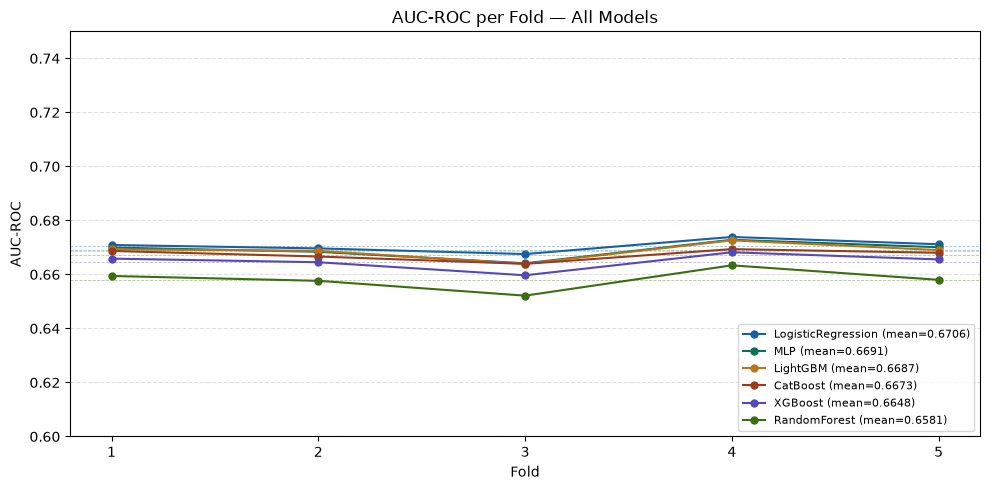

Saved AUC-ROC plot.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── AUC-ROC distribution per model ───────────────────────────────────────────
auc_summary = results_df.groupby("model")["auc_roc"].agg(["mean", "std"]).reset_index()
auc_summary = auc_summary.sort_values("mean", ascending=False)

colors = ['#185FA5', '#0F6E56', '#BA7517', '#993C1D', '#534AB7', '#3B6D11']

fig, ax = plt.subplots(figsize=(10, 5))

for i, row in auc_summary.iterrows():
    model_data = results_df[results_df["model"] == row["model"]]["auc_roc"].values
    folds = np.arange(1, len(model_data) + 1)
    color = colors[list(auc_summary["model"]).index(row["model"])]
    ax.plot(folds, model_data, marker='o', label=f"{row['model']} (mean={row['mean']:.4f})",
            color=color, linewidth=1.5, markersize=5)
    ax.axhline(row["mean"], color=color, linewidth=0.6, linestyle='--', alpha=0.4)

ax.set_xlabel("Fold")
ax.set_ylabel("AUC-ROC")
ax.set_title("AUC-ROC per Fold — All Models")
ax.set_xticks(range(1, 6))
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0.60, 0.75)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "auc_roc_per_fold.png", dpi=150)
plt.show()
print("Saved AUC-ROC plot.")

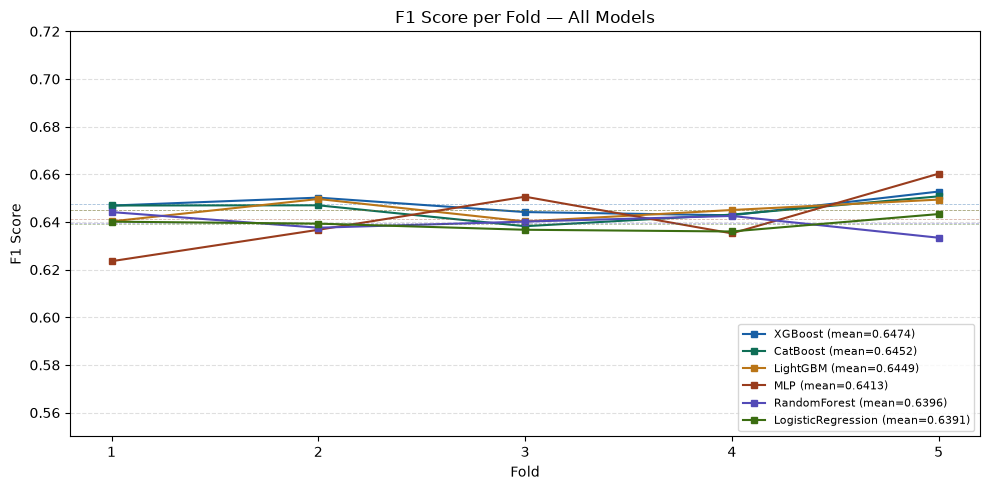

Saved F1 plot.


In [8]:
f1_summary = results_df.groupby("model")["f1"].agg(["mean", "std"]).reset_index()
f1_summary = f1_summary.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

for i, row in f1_summary.iterrows():
    model_data = results_df[results_df["model"] == row["model"]]["f1"].values
    folds = np.arange(1, len(model_data) + 1)
    color = colors[list(f1_summary["model"]).index(row["model"])]
    ax.plot(folds, model_data, marker='s', label=f"{row['model']} (mean={row['mean']:.4f})",
            color=color, linewidth=1.5, markersize=5)
    ax.axhline(row["mean"], color=color, linewidth=0.6, linestyle='--', alpha=0.4)

ax.set_xlabel("Fold")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score per Fold — All Models")
ax.set_xticks(range(1, 6))
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0.55, 0.72)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "f1_per_fold.png", dpi=150)
plt.show()
print("Saved F1 plot.")

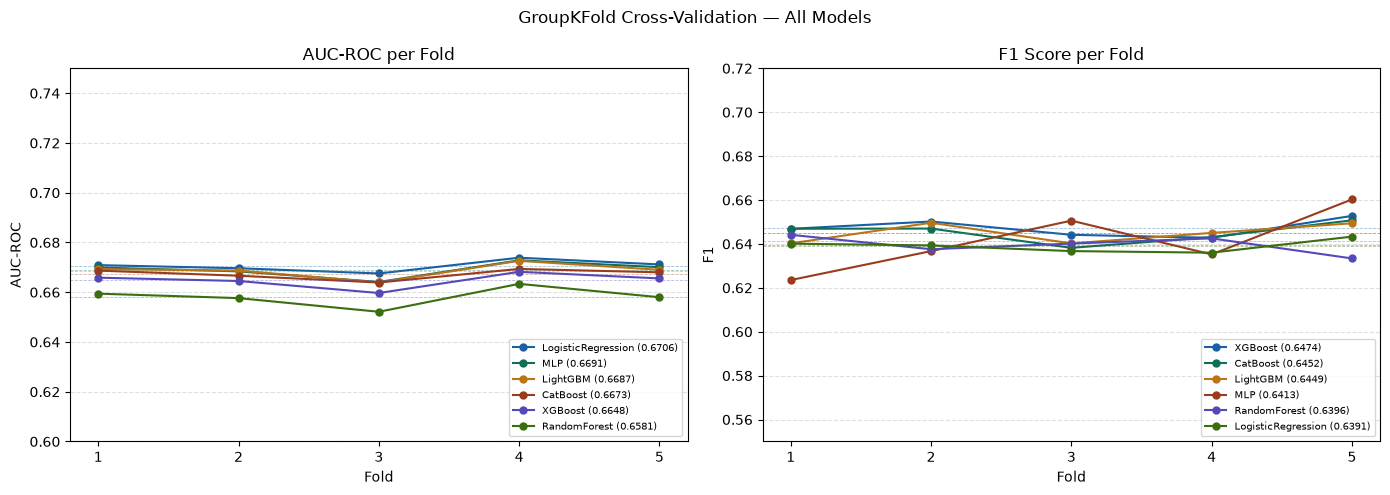

Saved combined metrics plot.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title, ylim in zip(
    axes,
    ["auc_roc", "f1"],
    ["AUC-ROC per Fold", "F1 Score per Fold"],
    [(0.60, 0.75), (0.55, 0.72)]
):
    summary = results_df.groupby("model")[metric].mean().sort_values(ascending=False)
    for j, model_name in enumerate(summary.index):
        model_data = results_df[results_df["model"] == model_name][metric].values
        folds = np.arange(1, len(model_data) + 1)
        ax.plot(folds, model_data, marker='o',
                label=f"{model_name} ({summary[model_name]:.4f})",
                color=colors[j], linewidth=1.5, markersize=5)
        ax.axhline(summary[model_name], color=colors[j],
                   linewidth=0.6, linestyle='--', alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric.replace("_", "-").upper())
    ax.set_xticks(range(1, 6))
    ax.set_ylim(ylim)
    ax.legend(fontsize=7.5, loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle("GroupKFold Cross-Validation — All Models", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "metrics_per_fold_combined.png", dpi=150)
plt.show()
print("Saved combined metrics plot.")

In [10]:
best_model_name = summary_sorted["f1"].idxmax()
print(f"Best model by F1: {best_model_name}")

final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

final_model = MODELS[best_model_name]()
final_model.fit(X_res, y_res)

MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, MODELS_DIR / "best_model.pkl")
joblib.dump(final_scaler, MODELS_DIR / "scaler.pkl")

background_sample = X_scaled[:100]
joblib.dump(background_sample, MODELS_DIR / "background_sample.pkl")
joblib.dump(feature_names, FEATURE_NAMES_PATH)

print(f"Saved best_model.pkl ({best_model_name}), scaler.pkl, background_sample.pkl, and feature_names.pkl to {MODELS_DIR}")


Best model by F1: XGBoost
Saved best_model.pkl (XGBoost), scaler.pkl, background_sample.pkl, and feature_names.pkl to C:\Users\hamna\Desktop\MediAlert\models


In [11]:
variance = results_df.groupby("model")["f1"].agg(["mean", "std", "min", "max"]).sort_values("mean", ascending=False)
print(variance)


                        mean       std       min       max
model                                                     
XGBoost             0.647371  0.004142  0.642808  0.652773
CatBoost            0.645204  0.004748  0.638230  0.650764
LightGBM            0.644916  0.004640  0.640238  0.649652
MLP                 0.641279  0.014313  0.623549  0.660273
RandomForest        0.639575  0.004249  0.633401  0.644163
LogisticRegression  0.639109  0.002916  0.636023  0.643327


In [12]:
from scipy import stats

winner_scores = results_df[results_df["model"] == best_model_name].sort_values("fold")["f1"].values

print(f"Paired t-test: {best_model_name} vs each other model\n")
for other_model in summary_sorted.index:
    if other_model == best_model_name:
        continue
    other_scores = results_df[results_df["model"] == other_model].sort_values("fold")["f1"].values
    stat, p = stats.ttest_rel(winner_scores, other_scores)
    significance = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"{best_model_name} vs {other_model}: p = {p:.4f}  ({significance})")


Paired t-test: XGBoost vs each other model

XGBoost vs CatBoost: p = 0.1314  (not significant)
XGBoost vs LightGBM: p = 0.1802  (not significant)
XGBoost vs MLP: p = 0.3602  (not significant)
XGBoost vs RandomForest: p = 0.0940  (not significant)
XGBoost vs LogisticRegression: p = 0.0006  (SIGNIFICANT)


In [13]:
# Threshold optimization for the deployed model


from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score
import numpy as np

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, threshold_val_idx = next(gss.split(X, y, groups))

X_thresh_train, X_thresh_val = X.iloc[train_val_idx], X.iloc[threshold_val_idx]
y_thresh_train, y_thresh_val = y.iloc[train_val_idx], y.iloc[threshold_val_idx]


thresh_scaler = StandardScaler()
X_thresh_train_scaled = thresh_scaler.fit_transform(X_thresh_train)
X_thresh_val_scaled = thresh_scaler.transform(X_thresh_val)

sm = SMOTE(random_state=42)
X_thresh_train_res, y_thresh_train_res = sm.fit_resample(X_thresh_train_scaled, y_thresh_train)

thresh_model = MODELS[best_model_name]()
thresh_model.fit(X_thresh_train_res, y_thresh_train_res)

y_val_proba = thresh_model.predict_proba(X_thresh_val_scaled)[:, 1]

thresholds = np.arange(0.30, 0.70, 0.02)
best_f1, best_threshold = 0.0, 0.5
threshold_results = []
for t in thresholds:
    preds = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_thresh_val, preds)
    threshold_results.append({"threshold": round(t, 2), "f1": f1})
    if f1 > best_f1:
        best_f1, best_threshold = f1, t

print(f"Default threshold (0.50) F1 on this validation split: "
      f"{f1_score(y_thresh_val, (y_val_proba >= 0.5).astype(int)):.4f}")
print(f"Best threshold found: {best_threshold:.2f}  |  F1 at best threshold: {best_f1:.4f}")

import pandas as pd
threshold_df = pd.DataFrame(threshold_results)
print("\nFull threshold sweep:")
print(threshold_df.to_string(index=False))

import json
with open(MODELS_DIR / "optimal_threshold.json", "w") as f:
    json.dump({
        "model": best_model_name,
        "optimal_threshold": float(best_threshold),
        "f1_at_optimal_threshold": float(best_f1),
        "f1_at_default_threshold": float(f1_score(y_thresh_val, (y_val_proba >= 0.5).astype(int))),
        "note": "Selected on a held-out GroupShuffleSplit validation set, not on any benchmarking test fold. Not used by the live API (see backend/model.py risk_level_from_probability).",
    }, f, indent=2)
print(f"\nSaved threshold record to {MODELS_DIR / 'optimal_threshold.json'}")

Default threshold (0.50) F1 on this validation split: 0.6449
Best threshold found: 0.32  |  F1 at best threshold: 0.7016

Full threshold sweep:
 threshold       f1
      0.30 0.699354
      0.32 0.701628
      0.34 0.700905
      0.36 0.700072
      0.38 0.698890
      0.40 0.698143
      0.42 0.691869
      0.44 0.681163
      0.46 0.673473
      0.48 0.658962
      0.50 0.644863
      0.52 0.623840
      0.54 0.598913
      0.56 0.568163
      0.58 0.534889
      0.60 0.495330
      0.62 0.458493
      0.64 0.414910
      0.66 0.374605
      0.68 0.327646

Saved threshold record to C:\Users\hamna\Desktop\MediAlert\models\optimal_threshold.json
